In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Design Spaces and the Big Picture

Every architecture in this chapter was designed by hand. AlexNet (that section) established that deep networks beat feature engineering; VGG (that section) organized convolutions into repeated blocks of $3 \times 3$ kernels; NiN (that section) mixed channels with $1 \times 1$ convolutions and aggregated with global pooling; GoogLeNet (that section) combined branches of different convolution widths; ResNet (that section) rebiased networks towards the identity mapping, making great depth trainable; and ResNeXt (that section) added grouped convolutions for a better parameter--computation trade-off. This *network engineering* succeeded, but each step depended on the intuition of its designers rather than on any systematic exploration of the space of possible networks.

One alternative is *neural architecture search* (NAS) [@zoph2016neural; @liu2018darts]: fix a search space, then let a search strategy (reinforcement learning, evolutionary algorithms, or gradient-based relaxations) select an architecture based on estimated performance. EfficientNet is a prominent product of this approach [@tan2019efficientnet]. But the cost is usually enormous, and the outcome is a *single network instance*: we learn that it works, not why.

This section covers a middle way due to @Radosavovic.Kosaraju.Girshick.ea.2020: *designing network design spaces*. Instead of hunting for the single best network, we study *distributions over networks* and tune the parameters of the distribution so that a typical member performs well. This is far cheaper than NAS, and it yields transferable design principles rather than one opaque winner. The outcome is the *RegNet* family (RegNetX and RegNetY). This way of thinking, characterizing whole populations of models by a few simple empirical laws instead of championing individual instances, is the direct ancestor of the scaling-law analyses that guide model design today.

In [1]:
from d2l import jax as d2l
from flax import nnx
import jax

## The AnyNet Design Space

Following @Radosavovic.Kosaraju.Girshick.ea.2020, we first need a template for the family of networks to explore. A commonality of the designs in this chapter is that networks consist of a *stem*, a *body*, and a *head*. The stem performs initial image processing, often via convolutions with a larger window size. The body carries out the bulk of the transformation from raw images to object representations; it consists of multiple *stages* that operate on the image at decreasing resolutions, each stage built from one or more *blocks*. The head converts the result into the desired output, for instance via a softmax regressor for multiclass classification. This pattern is common to all networks from VGG to ResNeXt; for generic AnyNet networks, @Radosavovic.Kosaraju.Girshick.ea.2020 used the ResNeXt block of the figure.

![The AnyNet design space: a stem, a body of four stages, and a head. Each stage container holds $\mathit{d_i}$ ResNeXt blocks producing $\mathit{c_i}$ channels; the first block of a stage halves the resolution. The $(\mathit{c}, \mathit{r})$ annotations give the number of channels $\mathit{c}$ and the resolution $\mathit{r} \times \mathit{r}$ at each point. Design choices per stage $\mathit{i}$: depth $\mathit{d_i}$, output channels $\mathit{c_i}$, number of groups $\mathit{g_i}$, and bottleneck ratio $\mathit{k_i}$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/arch-anynet.svg)

Let's review the structure of the figure in detail. The stem takes RGB images (3 channels) and applies a $3 \times 3$ convolution with a stride of $2$, followed by batch norm, halving the resolution from $r \times r$ to $r/2 \times r/2$ and producing $c_0$ channels that serve as input to the body.

Since the network is designed for ImageNet images of shape $224 \times 224 \times 3$, the body reduces this to $7 \times 7 \times c_4$ through 4 stages (recall that $224 / 2^{1+4} = 7$), each with an eventual stride of $2$. The head is entirely standard: global average pooling, as in NiN (that section), followed by a fully connected layer emitting an $n$-dimensional vector for $n$-class classification.

Most of the design decisions live in the body. Each stage begins with a block that halves the resolution using a stride of $2$ (the rightmost in the figure); to match shapes, its residual branch passes through a $1 \times 1$ convolution. This block is followed by a variable number of ResNeXt blocks that leave both resolution and channel count unchanged. Each block may narrow its internal channels by a bottleneck ratio $k_i \geq 1$, affording $c_i/k_i$ channels inside the block for stage $i$ (as the experiments will show, this is not really effective and should be skipped). Since we use ResNeXt blocks, we must also pick the number of groups $g_i$ for grouped convolutions at stage $i$.

This seemingly generic design space still leaves many parameters: block widths $c_0, \ldots c_4$, depths per stage $d_1, \ldots d_4$, bottleneck ratios $k_1, \ldots k_4$, and group widths $g_1, \ldots g_4$, a total of 17 parameters and an unreasonably large number of configurations to explore. We will need tools to reduce this design space effectively. But first, let's implement the generic design.

In [2]:
class AnyNet(d2l.Classifier):
    def __init__(self, arch, stem_channels, lr=0.1, num_classes=10,
                 in_channels=1, rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['rngs'])
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        self.net = self.create_net(in_channels, rngs)

    def stem(self, in_channels, num_channels, rngs):
        return nnx.Sequential(
            nnx.Conv(in_channels, num_channels, kernel_size=(3, 3),
                     strides=(2, 2), padding=(1, 1), rngs=rngs),
            nnx.BatchNorm(num_channels, rngs=rngs), nnx.relu)

Each stage consists of `depth` ResNeXt blocks,
where `num_channels` specifies the block width.
Note that the first block halves the height and width of input images.

In [3]:
@d2l.add_to_class(AnyNet)
def stage(self, depth, num_channels, groups, bot_mul, in_channels, rngs):
    blk = []
    for i in range(depth):
        if i == 0:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul,
                use_1x1conv=True, strides=(2, 2), in_channels=in_channels,
                rngs=rngs))
        else:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul,
                                        in_channels=num_channels, rngs=rngs))
    return nnx.Sequential(*blk)

Putting the network stem, body, and head together,
we complete the implementation of AnyNet.

In [4]:
@d2l.add_to_class(AnyNet)
def create_net(self, in_channels, rngs):
    layers = [self.stem(in_channels, self.stem_channels, rngs)]
    stage_channels = self.stem_channels
    for s in self.arch:
        layers.append(self.stage(*s, stage_channels, rngs))
        stage_channels = s[1]
    layers.append(nnx.Sequential(
        lambda x: x.mean(axis=(1, 2)),  # global avg pooling over H, W (NHWC)
        nnx.Linear(stage_channels, self.num_classes, rngs=rngs)))
    return nnx.Sequential(*layers)

## Distributions and Parameters of Design Spaces

Parameters of a design space are hyperparameters of networks in that design space. Consider the problem of identifying good parameters in the AnyNet design space. We could try to find the *single best* parameter choice for a given amount of computation (e.g., FLOPs). But even with only *two* possible choices per parameter, we would have to explore $2^{17} = 131072$ combinations. Worse, exhaustive search teaches us nothing about *how* to design a network: add a new stage type or operation and we start from scratch, and training stochasticity (rounding, shuffling) means no two runs produce exactly the same result anyway. A better strategy is to determine general guidelines for how parameter choices should be related, e.g., that the bottleneck ratio, the number of channels, blocks, and groups, or their change between stages, should be governed by a collection of simple rules. The approach in @radosavovic2019network relies on the following four assumptions:

1. General design principles actually exist, so that many networks satisfying them offer good performance. Consequently, identifying a *distribution* over networks is a sensible strategy: there are many good needles in the haystack.
1. We need not train networks to convergence to assess whether they are good; intermediate results are reliable guidance for final accuracy. Using such approximate proxies to optimize an objective is referred to as multi-fidelity optimization [@forrester2007multi]. Design optimization is thus carried out based on the accuracy achieved after only a few passes through the dataset, reducing the cost significantly.
1. Results obtained at a smaller scale (with fewer blocks and channels) generalize to larger ones, so optimization is carried out on structurally similar but smaller networks; only at the end do we verify that the resulting networks also perform well at scale.
1. Aspects of the design can be approximately factorized, so that their effect on the outcome can be inferred somewhat independently.

These assumptions allow us to test many networks cheaply: we *sample* uniformly from the space of configurations and then judge a choice of design-space parameters by the *distribution* of errors it produces. Denote by $F(e)$ the cumulative distribution function (CDF) for errors committed by networks of a given design space, drawn using probability distribution $p$. That is,

$$F(e, p) \stackrel{\textrm{def}}{=} P_{\textrm{net} \sim p} \{e(\textrm{net}) \leq e\}.$$

Our goal is to find a distribution $p$ over *networks* such that most networks have a very low error rate and the support of $p$ is concise. Computing $F$ exactly is infeasible, so we resort to a sample of networks $\mathcal{Z} \stackrel{\textrm{def}}{=} \{\textrm{net}_1, \ldots \textrm{net}_n\}$ (with errors $e_1, \ldots, e_n$, respectively) drawn from $p$ and use the empirical CDF $\hat{F}(e, \mathcal{Z})$ instead:

$$\hat{F}(e, \mathcal{Z}) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(e_i \leq e).$$

Whenever the CDF for one set of choices majorizes (or matches) another CDF, its choice of parameters is superior (or indifferent). This gives us a cheap experimental protocol: constrain the design space, draw networks from the constrained and the unconstrained distribution, and compare the two CDFs. Accordingly, @Radosavovic.Kosaraju.Girshick.ea.2020 tried a shared bottleneck ratio $k_i = k$ for all stages $i$, removing three of the four bottleneck parameters. As the first panel of the figure shows, this constraint does not affect the error distribution at all. Sharing the group width $g_i = g$ across stages is equally harmless (second panel). Both steps combined remove six free parameters.

![Comparing error empirical distribution functions of design spaces. $\textrm{AnyNet}_{\mathit{A}}$ is the original design space; $\textrm{AnyNet}_{\mathit{B}}$ ties the bottleneck ratios, $\textrm{AnyNet}_{\mathit{C}}$ also ties group widths, $\textrm{AnyNet}_{\mathit{D}}$ increases the network depth across stages. From left to right: (i) tying bottleneck ratios has no effect on performance; (ii) tying group widths has no effect on performance; (iii) increasing network widths (channels) across stages improves performance; (iv) increasing network depths across stages improves performance. Figure courtesy of @Radosavovic.Kosaraju.Girshick.ea.2020.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/regnet-fig.png)

Next we reduce the choices for width and depth of the stages. It is reasonable to assume that channels increase with depth, i.e., $c_i \geq c_{i-1}$ ($w_{i+1} \geq w_i$ per their notation in the figure), yielding $\textrm{AnyNetX}_D$, and likewise that later stages are deeper, i.e., $d_i \geq d_{i-1}$, yielding $\textrm{AnyNetX}_E$. The third and fourth panels of the figure verify both experimentally.

## RegNet

The resulting $\textrm{AnyNetX}_E$ design space consists of simple networks
following easy-to-interpret design principles:

* Share the bottleneck ratio $k_i = k$ for all stages $i$;
* Share the group width $g_i = g$ for all stages $i$;
* Increase network width across stages: $c_{i} \leq c_{i+1}$;
* Increase network depth across stages: $d_{i} \leq d_{i+1}$.

It remains to pick specific values for the parameters of the $\textrm{AnyNetX}_E$ design space. Studying the best-performing networks from its distribution shows that network width ideally increases linearly with the block index $j$ across the network, i.e., $c_j \approx c_0 + c_a j$ with slope $c_a > 0$; since block width can only change per stage, we arrive at a piecewise constant function engineered to match this dependence. Experiments also show that a bottleneck ratio of $k = 1$ performs best, i.e., we are advised not to use bottlenecks at all.

We refer the interested reader to @Radosavovic.Kosaraju.Girshick.ea.2020 for the design of specific networks at different amounts of computation. For instance, an effective 32-layer RegNetX variant is given by $k = 1$ (no bottleneck), $g = 16$ (group width 16), with $c_1 = 32$ and $c_2 = 80$ channels for the first and second stage, respectively, chosen to be $d_1=4$ and $d_2=6$ blocks deep. These design principles continue to hold at larger scale, and they carry over to the Squeeze-and-Excitation variant (RegNetY) that adds a global channel activation [@Hu.Shen.Sun.2018], which we describe below.

In [5]:
class RegNetX32(AnyNet):
    def __init__(self, lr=0.1, num_classes=10, in_channels=1, rngs=None):
        super().__init__(((4, 32, 16, 1), (6, 80, 16, 1)), 32,
                         lr, num_classes, in_channels, rngs)

We can see that each RegNetX stage progressively reduces resolution and increases output channels.

In [6]:
RegNetX32().layer_summary((1, 96, 96, 1))

Sequential output shape:	 (1, 48, 48, 32)


Sequential output shape:	 (1, 24, 24, 32)


Sequential output shape:	 (1, 12, 12, 80)


Sequential output shape:	 (1, 10)


### Squeeze-and-Excitation Gates

The global channel activation that turns RegNetX into RegNetY is the *squeeze-and-excitation* (SE) gate [@Hu.Shen.Sun.2018]. A convolution mixes information locally; an SE gate lets the network reweight entire channels based on global context. It *squeezes* each channel to a single number by global average pooling, passes the resulting vector of $c$ channel summaries through a two-layer bottleneck MLP with a sigmoid output (the *excitation*), and multiplies each channel of the input by its gate value. The extra cost is negligible, about $2c^2/r$ parameters for reduction ratio $r$ and almost no FLOPs, since the MLP acts on a pooled vector rather than on the feature map. This is a simple form of attention, computed per channel rather than per location; the general mechanism is the subject of that section. The gate outlived its namesake network: EfficientNet [@tan2019efficientnet] and most of the mobile architectures of that section include SE blocks.

An SE gate is only a few lines: pool, two dense layers, rescale.

In [7]:
class SE(nnx.Module):
    def __init__(self, num_channels, ratio=4, rngs=None):
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        self.squeeze = nnx.Linear(num_channels, num_channels // ratio,
                                  rngs=rngs)
        self.excite = nnx.Linear(num_channels // ratio, num_channels,
                                 rngs=rngs)

    def __call__(self, X):
        s = X.mean(axis=(1, 2))
        s = nnx.relu(self.squeeze(s))
        s = nnx.sigmoid(self.excite(s))
        return X * s[:, None, None, :]

X = jax.random.normal(d2l.get_key(), (2, 16, 16, 32))
SE(32)(X).shape

(2, 16, 16, 32)

The output has the same shape as the input: an SE gate can be dropped into any block, which is exactly how RegNetY, EfficientNet, and their successors use it.

## Training

Training the 32-layer RegNetX on the Fashion-MNIST dataset is just like before.

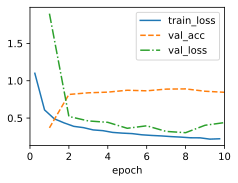

In [8]:
model = RegNetX32(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

## The Big Picture: ConvNets and Transformers

For most of a decade, the networks in this chapter defined the state of the art in computer vision. Then vision Transformers (that section) [@Dosovitskiy.Beyer.Kolesnikov.ea.2021; @touvron2021training], which have far weaker inductive biases towards locality and translation equivariance (that section), surpassed CNNs on large-scale image classification, and it became common to read that convolution was obsolete. The evidence that has accumulated since is more precise.

First, the scaling question was settled. When convolutional networks are given modern training recipes and the same compute budget as vision Transformers, they keep up: NFNets [@brock2021nfnet] pretrained at JFT-4B scale match ViT accuracy at equal compute [@smith2023convnets], and modernizing the recipe (that section) and architecture of a ResNet yields ConvNeXt (that section) [@liu2022convnet], which is competitive with contemporary Transformers. The apparent gap between the two families around 2021 was mostly a gap in recipe and scale, not in representational power.

What remains is a division of labor. Foundation-scale pretraining and multimodal systems belong to the Transformer: it trains on billion-scale image--text corpora, and it plugs directly into the tooling, scaling infrastructure, and language models built around the same architecture (that section). Convolutional networks own the regimes where their inductive bias pays: latency-constrained and edge deployment, small datasets, and much of dense prediction. In medical image segmentation, nnU-Net, a self-configuring convolutional U-Net, still wins controlled benchmarks [@isensee2021nnunet]. And convolutions persist *inside* Transformers: Whisper, for example, feeds its Transformer encoder from a convolutional stem [@radford2023whisper]. that section covers the deployment side of this division in detail.

The same pattern holds beyond classification. Diffusion image generators moved from convolutional U-Nets to diffusion Transformers at the frontier [@peebles2023dit], while convolutional U-Nets remain standard in deployed and smaller systems.

The lesson of the chapter, then, is that inductive bias is a data-efficiency dial, not a ceiling. With limited data and compute, locality and translation equivariance buy accuracy that a less constrained model must learn from examples; with enough of both, a Transformer learns those regularities and others besides. that section develops that architecture in full.

## Exercises

1. Increase the number of stages to four. Can you design a deeper RegNetX that performs better?
1. De-ResNeXt-ify RegNets by replacing the ResNeXt block with the ResNet block. How does your new model perform?
1. Implement multiple instances of a "VioNet" family by *violating* the design principles of RegNetX. How do they perform? Which of ($d_i$, $c_i$, $g_i$, $b_i$) is the most important factor?
1. The AnyNet experiments used the ResNeXt block throughout. Apply the same methodology to a design space built from ConvNeXt blocks (that section): sample configurations, compare empirical CDFs, and check which of the RegNet design principles survive the change of block.

[Discussions](https://d2l.discourse.group/t/18009)